<a href="https://colab.research.google.com/github/prof-atritiack/CP2-SERS-1CCPJ-ML/blob/main/CP2_SERS_1CCPJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##EXERCÍCIO

Treinar um modelo de classificação usando o algoritmo de regressão logística (no sklearn ---> Logistic Regression) para prever se a rede elétrica está INSTÁVEL ou ESTÁVEL. Métricas para avaliação: acurácia, precisão e a matriz de confusão.

Qual será o atributo alvo y (target)? ----> coluna 'stabf' com duas classes 'stable' e 'unstable'

Quais serão as nossas features (X)?  ----> todos os atributos, exceto 'stab' e 'stabf'

## PREPARAÇÃO DO AMBIENTE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

CARREGAR OS DADOS DO ARQUIVO DA PASTA DO GitHub USANDO PANDAS (read_csv)

In [3]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CP2-SERS-1CCPJ-ML/refs/heads/main/Data_for_UCI_named.csv')
dados.head(15)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


## INSPEÇÃO (ANÁLISE EXPLORATÓRIA)

In [4]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [10]:
dados.shape
print(f'Registros: {dados.shape[0]}')
print(f'Colunas: {dados.shape[1]}')

Registros: 10000
Colunas: 14


In [11]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [12]:
# Atributos com dados categóricos
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [13]:
# Atributos com dados numéricos
dados.describe(include='number')

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [ ]:
# Renomeando 'labels' das classes
dados['stabf'] = dados['stabf'].replace({'unstable': 'REDE INSTÁVEL', 'stable': 'REDE ESTÁVEL'})
dados.head(15)

In [17]:
# Quais classes existem na coluna alvo "stabf"?
dados['stabf'].unique()

array(['REDE INSTÁVEL', 'REDE ESTÁVEL'], dtype=object)

In [18]:
# Quantos registros temos de cada classe?
dados['stabf'].value_counts()

,count
stabf,
REDE INSTÁVEL,6380
REDE ESTÁVEL,3620


In [19]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [20]:
# Features
# Separar features (X)
X = dados.drop(['stab', 'stabf'], axis=1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [22]:
# Separar target (y)
y = dados['stabf']
y.head()

,stabf
0,REDE INSTÁVEL
1,REDE ESTÁVEL
2,REDE INSTÁVEL
3,REDE INSTÁVEL
4,REDE INSTÁVEL


In [23]:
# Separar dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Instanciar o objeto 'modelo' a partir da classe LogisticRegression
modelo = LogisticRegression()

In [25]:
# Treinar
modelo.fit(X_train, y_train)

LogisticRegression()

In [27]:
# Gerar as probabilidades
y_prob = modelo.predict_proba(X_test)
y_prob[:50] # 50 registros

array([[0.04609348, 0.95390652],
       [0.06082634, 0.93917366],
       [0.31665189, 0.68334811],
       [0.97845447, 0.02154553],
       [0.64488737, 0.35511263],
       [0.57310264, 0.42689736],
       [0.7293308 , 0.2706692 ],
       [0.0220369 , 0.9779631 ],
       [0.04455238, 0.95544762],
       [0.74263825, 0.25736175],
       [0.05821672, 0.94178328],
       [0.43539611, 0.56460389],
       [0.54821046, 0.45178954],
       [0.22628137, 0.77371863],
       [0.01738045, 0.98261955],
       [0.24059749, 0.75940251],
       [0.43383254, 0.56616746],
       [0.19235057, 0.80764943],
       [0.42956875, 0.57043125],
       [0.30915071, 0.69084929],
       [0.08327983, 0.91672017],
       [0.1285647 , 0.8714353 ],
       [0.19005429, 0.80994571],
       [0.77021981, 0.22978019],
       [0.34514059, 0.65485941],
       [0.29155465, 0.70844535],
       [0.61401301, 0.38598699],
       [0.48196263, 0.51803737],
       [0.69575885, 0.30424115],
       [0.92903344, 0.07096656],
       [0.

In [28]:
# Gerar as previsões
y_pred = modelo.predict(X_test)
y_pred[:50] # 50 registros

array(['REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE ESTÁVEL',
       'REDE ESTÁVEL', 'REDE ESTÁVEL', 'REDE ESTÁVEL', 'REDE INSTÁVEL',
       'REDE INSTÁVEL', 'REDE ESTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL',
       'REDE ESTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL',
       'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL',
       'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE ESTÁVEL',
       'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE ESTÁVEL', 'REDE INSTÁVEL',
       'REDE ESTÁVEL', 'REDE ESTÁVEL', 'REDE INSTÁVEL', 'REDE ESTÁVEL',
       'REDE ESTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL',
       'REDE ESTÁVEL', 'REDE ESTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL',
       'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE INSTÁVEL', 'REDE ESTÁVEL',
       'REDE ESTÁVEL', 'REDE INSTÁVEL', 'REDE ESTÁVEL', 'REDE INSTÁVEL',
       'REDE ESTÁVEL', 'REDE ESTÁVEL'], dtype=object)

In [30]:
# Acurácia
accuracy = 100 * accuracy_score(y_test, y_pred)
print(f'Acurácia: {accuracy:.2f}%')

Acurácia: 81.70%


In [ ]:
# Gerar a matriz de confusão, usando heatmap e seaborn

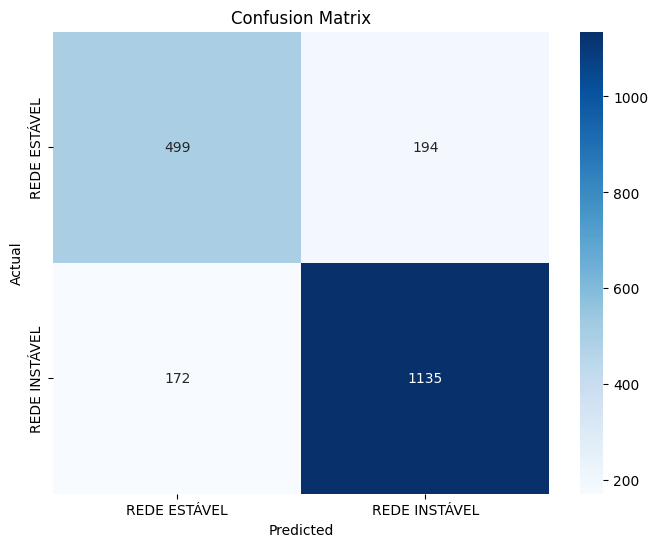

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()